In [ ]:
from functools import reduce
import pandas as pd
import requests
import time
import json
import os
os.makedirs("raw_cache", exist_ok=True)

def find_who_indicator(search_term):
    """Query WHO's own indicator registry to find the correct code for a
    topic, instead of guessing a code from memory. Returns a DataFrame of
    matches so you can pick the exact one you want."""
    url = f"https://ghoapi.azureedge.net/api/Indicator?$filter=contains(IndicatorName,'{search_term}')"
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    data = resp.json().get("value", [])
    return pd.DataFrame(data)[["IndicatorCode", "IndicatorName"]] if data else pd.DataFrame()

for term in ["Dengue", "Cholera", "air pollution", "Malaria", "Life expectancy"]:
    matches = find_who_indicator(term)
    print(f"\n--- matches for '{term}' ---")
    print(matches.to_string(index=False) if not matches.empty else "  NO MATCHES FOUND")
    time.sleep(0.3)


--- matches for 'Dengue' ---
  NO MATCHES FOUND

--- matches for 'Cholera' ---
     IndicatorCode                          IndicatorName
CHOLERA_0000000002 Number of reported deaths from cholera
CHOLERA_0000000001    Number of reported cases of cholera
CHOLERA_0000000003             Cholera case fatality rate
           WHS3_40     Cholera - number of reported cases

--- matches for 'air pollution' ---
IndicatorCode                                                                                          IndicatorName
       AIR_10                           Ambient air pollution  attributable DALYs per 100'000 children under 5 years
       AIR_12                                  Household air pollution attributable deaths in children under 5 years
       AIR_16                                   Household air pollution attributable DALYs in children under 5 years
       AIR_35                                                     Joint effects of air pollution attributable deaths
       A

In [ ]:
who_indicators = {
    "MALARIA_EST_CASES": "malaria_cases",
    "WHOSIS_000001": "life_expectancy",
    "CHOLERA_0000000001": "cholera_cases",
    "AIR_41": "air_pollution_deaths",
}

def fetch_who_indicator(code, col_name):
    url = f"https://ghoapi.azureedge.net/api/{code}"
    try:
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
    except requests.RequestException as e:
        print(f"  [FAILED] {code}: {e}")
        return None
    payload = resp.json()
    with open(f"raw_cache/who_{code}.json", "w") as f:
        json.dump(payload, f)
    records = payload.get("value", [])
    if not records:
        print(f"  [WARNING] {code} returned 0 records — code is likely wrong or deprecated")
        return None
    df = pd.DataFrame(records)
    df = df[df["SpatialDimType"] == "COUNTRY"]
    if df.empty:
        print(f"  [WARNING] {code} had records but none at COUNTRY level")
        return None
    df = df[["SpatialDim", "TimeDim", "NumericValue"]].copy()
    df.columns = ["country_code", "year", col_name]
    df["year"] = df["year"].astype(int)
    df = df.groupby(["country_code", "year"])[col_name].mean().reset_index()

    print(f"  [OK] {code} -> '{col_name}': {len(df)} country-year records, "
          f"{df['country_code'].nunique()} countries, years {df['year'].min()}-{df['year'].max()}")
    return df

print("Fetching WHO data...")
who_dfs = []
for code, col_name in who_indicators.items():
    df = fetch_who_indicator(code, col_name)
    if df is not None:
        who_dfs.append(df)
    time.sleep(0.3)
if not who_dfs:
    raise RuntimeError("No WHO indicators fetched successfully — check codes above")

who_master = reduce(
    lambda left, right: pd.merge(left, right, on=["country_code", "year"], how="outer"),
    who_dfs,
)
print(f"\nWHO master: {who_master.shape[0]} rows, {who_master.shape[1]} columns")

Fetching WHO data...
  [OK] MALARIA_EST_CASES -> 'malaria_cases': 2723 country-year records, 110 countries, years 2000-2024
  [OK] WHOSIS_000001 -> 'life_expectancy': 4070 country-year records, 185 countries, years 2000-2021
  [OK] CHOLERA_0000000001 -> 'cholera_cases': 2469 country-year records, 161 countries, years 1949-2016
  [OK] AIR_41 -> 'air_pollution_deaths': 185 country-year records, 185 countries, years 2021-2021

WHO master: 6025 rows, 6 columns


In [ ]:
wb_file = "https://raw.githubusercontent.com/SaniyaShaikh-sxc/climate-health-lifestyle-analysis/refs/heads/main/data/raw/API_EN.GHG.CO2.MT.CE.AR5_DS2_en_csv_v2_34526.csv"
wb = pd.read_csv(wb_file, skiprows=4)
wb = wb.rename(columns={
    "Country Code": "country_code"
})
wb = wb.melt(
    id_vars=["Country Name", "country_code", "Indicator Name", "Indicator Code"],
    var_name="year",
    value_name="co2_emissions"
)
wb["year"] = pd.to_numeric(wb["year"], errors="coerce")
wb = wb.dropna(subset=["country_code", "year", "co2_emissions"])
wb["year"] = wb["year"].astype(int)
wb_master = wb[["country_code", "year", "co2_emissions"]]

print(
    f"World Bank: {wb_master.shape[0]} rows, "
    f"{wb_master.shape[1]} columns"
)
print(wb_master.head())

World Bank: 13750 rows, 3 columns
     country_code  year  co2_emissions
2650          ABW  1970         0.0254
2651          AFE  1970       228.5328
2652          AFG  1970         1.7328
2653          AFW  1970        43.1109
2654          AGO  1970         8.9339


In [ ]:
merged_outer = pd.merge(
    who_master,
    wb_master,
    on=["country_code", "year"],
    how="outer"
)
merged_inner = pd.merge(
    who_master,
    wb_master,
    on=["country_code", "year"],
    how="inner"
)

print(f"Outer join: {merged_outer.shape[0]} rows")
print(f"Inner join: {merged_inner.shape[0]} rows  "
      f"({merged_inner.shape[0]/merged_outer.shape[0]:.1%} of outer)")
print("\nMissingness in outer-joined data:")
print(
    merged_outer.isna()
    .mean()
    .sort_values(ascending=False)
    .round(3)
)

merged_df = (
    merged_inner
    .sort_values(["country_code", "year"])
    .reset_index(drop=True)
)

merged_df.to_csv("raw_cache/merged_master.csv", index=False)

merged_df.head(10)

Outer join: 14050 rows
Inner join: 5725 rows  (40.7% of outer)

Missingness in outer-joined data:
air_pollution_deaths    0.987
cholera_cases           0.985
malaria_cases           0.806
life_expectancy         0.710
co2_emissions           0.021
year                    0.000
country_code            0.000
dtype: float64


,country_code,year,malaria_cases,life_expectancy,cholera_cases,air_pollution_deaths,co2_emissions
0,AFG,1993,NaN,NaN,NaN,NaN,1.7729
1,AFG,1994,NaN,NaN,NaN,NaN,1.6737
2,AFG,1995,NaN,NaN,NaN,NaN,1.4526
3,AFG,1997,NaN,NaN,NaN,NaN,1.3735
4,AFG,1998,NaN,NaN,NaN,NaN,1.4093
5,AFG,1999,NaN,NaN,NaN,NaN,1.3633
6,AFG,2000,1312939.0,53.834299,NaN,NaN,1.0093
7,AFG,2001,1312939.0,53.921629,NaN,NaN,0.9402
8,AFG,2002,1382972.0,55.159352,NaN,NaN,0.9388
9,AFG,2003,1242906.0,56.092501,NaN,NaN,1.0172


In [ ]:
print("Total rows in inner merge:", len(merged_inner))

print("\nRows with each variable available:")
for col in [
    "malaria_cases",
    "life_expectancy",
    "cholera_cases",
    "air_pollution_deaths",
    "co2_emissions"
]:
    print(f"{col}: {merged_inner[col].notna().sum()}")

print("\nRows with WHO + CO2 variables:")
print(
    merged_inner[
        [
            "malaria_cases",
            "life_expectancy",
            "cholera_cases",
            "air_pollution_deaths",
            "co2_emissions"
        ]
    ].notna().all(axis=1).sum()
)

Total rows in inner merge: 5725

Rows with each variable available:
malaria_cases: 2651
life_expectancy: 3982
cholera_cases: 213
air_pollution_deaths: 181
co2_emissions: 5725

Rows with WHO + CO2 variables:
0


In [ ]:
# Malaria + CO2
malaria_df = merged_inner.dropna(
    subset=["malaria_cases", "co2_emissions"]
).copy()

# Life expectancy + CO2
life_df = merged_inner.dropna(
    subset=["life_expectancy", "co2_emissions"]
).copy()

# Cholera + CO2
cholera_df = merged_inner.dropna(
    subset=["cholera_cases", "co2_emissions"]
).copy()

# Air pollution deaths + CO2
air_df = merged_inner.dropna(
    subset=["air_pollution_deaths", "co2_emissions"]
).copy()

print("Malaria + CO2:", len(malaria_df))
print("Life expectancy + CO2:", len(life_df))
print("Cholera + CO2:", len(cholera_df))
print("Air pollution + CO2:", len(air_df))

Malaria + CO2: 2651
Life expectancy + CO2: 3982
Cholera + CO2: 213
Air pollution + CO2: 181


In [ ]:
for name, df in [("malaria", malaria_df), ("life", life_df), ("cholera", cholera_df), ("air", air_df)]:
    print(f"{name}: {len(df)} rows | {df['country_code'].nunique()} countries | years {df['year'].min()}-{df['year'].max()}")
# this shows that there isnt enough data for cholera and barely any for air. this is the reason we take another dataset instead for air pollution that measures
# the exposure to pm 2.5 air instead of measuring mortality rate. we can compare this with co2 per capita and come to an environmental insight instead of the health
# insight we will arrive at with the other two datasets (malaria and life expectancy). we will not treat cholera as a time analysis / trend over the years parameter
# since a 5 year window (2011-16) only makes the graphs noisier. we can plot it/analyse it for a single point in time instead.

malaria: 2651 rows | 107 countries | years 2000-2024
life: 3982 rows | 181 countries | years 2000-2021
cholera: 213 rows | 70 countries | years 2011-2016
air: 181 rows | 181 countries | years 2021-2021


In [ ]:
for col in ["malaria_cases", "cholera_cases", "air_pollution_deaths", "life_expectancy"]:
    sub = who_master.dropna(subset=[col])
    print(f"{col}: years {sub['year'].min()}-{sub['year'].max()} | "
          f"n={len(sub)} | countries={sub['country_code'].nunique()}")

malaria_cases: years 2000-2024 | n=2723 | countries=110
cholera_cases: years 2011-2016 | n=216 | countries=71
air_pollution_deaths: years 2021-2021 | n=185 | countries=185
life_expectancy: years 2000-2021 | n=4070 | countries=185


In [ ]:
print(who_indicators)
who_dfs = []
for code, col_name in who_indicators.items():
    df = fetch_who_indicator(code, col_name)
    if df is not None:
        who_dfs.append(df)
who_master = reduce(
    lambda left, right: pd.merge(left, right, on=["country_code", "year"], how="outer"),
    who_dfs,
)
print(f"WHO master: {who_master.shape[0]} rows, {who_master.shape[1]} columns")

for col in ["malaria_cases", "cholera_cases", "air_pollution_deaths", "life_expectancy"]:
    sub = who_master.dropna(subset=[col])
    print(f"{col}: years {sub['year'].min()}-{sub['year'].max()} | "
          f"n={len(sub)} | countries={sub['country_code'].nunique()}")

{'MALARIA_EST_CASES': 'malaria_cases', 'WHOSIS_000001': 'life_expectancy', 'CHOLERA_0000000001': 'cholera_cases', 'AIR_41': 'air_pollution_deaths'}
  [OK] MALARIA_EST_CASES -> 'malaria_cases': 2723 country-year records, 110 countries, years 2000-2024
  [OK] WHOSIS_000001 -> 'life_expectancy': 4070 country-year records, 185 countries, years 2000-2021
  [OK] CHOLERA_0000000001 -> 'cholera_cases': 2469 country-year records, 161 countries, years 1949-2016
  [OK] AIR_41 -> 'air_pollution_deaths': 185 country-year records, 185 countries, years 2021-2021
WHO master: 6025 rows, 6 columns
malaria_cases: years 2000-2024 | n=2723 | countries=110
cholera_cases: years 2011-2016 | n=216 | countries=71
air_pollution_deaths: years 2021-2021 | n=185 | countries=185
life_expectancy: years 2000-2021 | n=4070 | countries=185


In [ ]:
pop_file = "https://raw.githubusercontent.com/SaniyaShaikh-sxc/climate-health-lifestyle-analysis/refs/heads/main/data/raw/API_SP.POP.TOTL_DS2_en_csv_v2_33112.csv"

pop = pd.read_csv(pop_file, skiprows=4)
pop = pop.rename(columns={"Country Code": "country_code"})

pop = pop.melt(
    id_vars=["Country Name", "country_code", "Indicator Name", "Indicator Code"],
    var_name="year", value_name="population"
)

pop["year"] = pd.to_numeric(pop["year"], errors="coerce")
pop = pop.dropna(subset=["country_code", "year", "population"])
pop["year"] = pop["year"].astype(int)

pop_master = pop[["country_code", "year", "population"]]

print(f"pop_master shape: {pop_master.shape}")
pop_master.head()

pop_master shape: (17394, 3)


,country_code,year,population
0,ABW,1960,54922.0
1,AFE,1960,130075728.0
2,AFG,1960,9035043.0
3,AFW,1960,97630925.0
4,AGO,1960,5231654.0


In [ ]:
merged_inner = merged_inner.drop(columns=["population"], errors="ignore")
merged_inner = merged_inner.merge(pop_master, on=["country_code", "year"], how="inner")
print(merged_inner.shape)
print(merged_inner.columns.tolist())
merged_inner["population"].describe()

(5725, 8)
['country_code', 'year', 'malaria_cases', 'life_expectancy', 'cholera_cases', 'air_pollution_deaths', 'co2_emissions', 'population']


,population
count,5.725000e+03
mean,4.489000e+07
std,1.499455e+08
min,7.298000e+03
25%,3.274400e+06
50%,1.016616e+07
75%,3.128457e+07
max,1.450936e+09


In [ ]:
print(merged_inner.columns.tolist())

['country_code', 'year', 'malaria_cases', 'life_expectancy', 'cholera_cases', 'air_pollution_deaths', 'co2_emissions', 'population']


In [ ]:
merged_inner["malaria_per_100k"] = merged_inner["malaria_cases"] / merged_inner["population"] * 1e5
merged_inner["cholera_per_100k"] = merged_inner["cholera_cases"] / merged_inner["population"] * 1e5
merged_inner["air_pollution_deaths_per_100k"] = merged_inner["air_pollution_deaths"] / merged_inner["population"] * 1e5
merged_inner["co2_per_capita"] = merged_inner["co2_emissions"] * 1e6 / merged_inner["population"]
merged_inner[["country_code", "year", "malaria_per_100k", "cholera_per_100k",
              "air_pollution_deaths_per_100k", "co2_per_capita"]].describe()

,year,malaria_per_100k,cholera_per_100k,air_pollution_deaths_per_100k,co2_per_capita
count,5725.000000,2651.000000,213.000000,181.000000,5725.000000
mean,2005.227249,9776.194606,23.984477,9.186022,4.222832
std,13.120187,14866.196641,99.281776,6.033033,6.097791
min,1970.000000,0.000000,0.000693,1.710987,0.000000
25%,2000.000000,4.809023,0.021994,5.480535,0.408920
50%,2007.000000,443.312990,0.568456,7.683338,1.732549
75%,2015.000000,17340.643257,5.388996,10.388257,5.942902
max,2024.000000,71178.923371,1112.994526,39.745277,72.068548


In [ ]:
merged_inner.sort_values("malaria_per_100k", ascending=False)[
    ["country_code", "year", "malaria_cases", "population", "malaria_per_100k"]
].head(15)

,country_code,year,malaria_cases,population,malaria_per_100k
4586,SLB,2004,337823.0,474611.0,71178.923371
4423,RWA,2017,8681013.0,12202060.0,71143.831451
4583,SLB,2001,285929.0,449125.0,63663.568049
4584,SLB,2002,280109.0,457671.0,61203.135003
431,BFA,2001,7346774.0,12295001.0,59754.155368
430,BFA,2000,7121621.0,11925546.0,59717.358014
432,BFA,2002,7513033.0,12680897.0,59246.857695
4587,SLB,2005,286015.0,483080.0,59206.549640
433,BFA,2003,7615906.0,13082532.0,58214.312031
4582,SLB,2000,254582.0,440469.0,57797.938107


In [ ]:
merged_inner["life_expectancy"].describe()

,life_expectancy
count,3982.000000
mean,70.185226
std,8.647625
min,40.160811
25%,64.479757
50%,72.253402
75%,76.704157
max,84.638818


metadata

In [ ]:
meta_file = "https://raw.githubusercontent.com/SaniyaShaikh-sxc/climate-health-lifestyle-analysis/refs/heads/main/data/raw/Metadata_Country_API_EN.GHG.CO2.MT.CE.AR5_DS2_en_csv_v2_34526.csv"
meta = pd.read_csv(meta_file)
meta = meta.rename(columns={"Country Code": "country_code"})
meta = meta[["country_code", "Region", "IncomeGroup", "TableName"]]
before = meta["country_code"].nunique()
meta = meta.dropna(subset=["IncomeGroup"])
print(f"Dropped {before - meta['country_code'].nunique()} non-country aggregate rows")
print(meta["IncomeGroup"].value_counts())

Dropped 47 non-country aggregate rows
IncomeGroup
High income            86
Upper middle income    59
Lower middle income    47
Low income             25
Name: count, dtype: int64


GDP

In [ ]:
gdp_file = "https://raw.githubusercontent.com/SaniyaShaikh-sxc/climate-health-lifestyle-analysis/refs/heads/main/data/raw/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_33610.csv"
gdp = pd.read_csv(gdp_file, skiprows=4)
gdp = gdp.rename(columns={"Country Code": "country_code"})
gdp = gdp.melt(
    id_vars=["Country Name", "country_code", "Indicator Name", "Indicator Code"],
    var_name="year", value_name="gdp_per_capita"
)
gdp["year"] = pd.to_numeric(gdp["year"], errors="coerce")
gdp = gdp.dropna(subset=["country_code", "year", "gdp_per_capita"])
gdp["year"] = gdp["year"].astype(int)
gdp_master = gdp[["country_code", "year", "gdp_per_capita"]]
print(f"gdp_master: {gdp_master.shape}")

gdp_master: (14745, 3)


In [ ]:
merged_inner = merged_inner.merge(gdp_master, on=["country_code", "year"], how="inner")
merged_inner = merged_inner.merge(meta, on="country_code", how="left")
print(merged_inner.shape)
print(merged_inner.columns.tolist())

(5602, 16)
['country_code', 'year', 'malaria_cases', 'life_expectancy', 'cholera_cases', 'air_pollution_deaths', 'co2_emissions', 'population', 'malaria_per_100k', 'cholera_per_100k', 'air_pollution_deaths_per_100k', 'co2_per_capita', 'gdp_per_capita', 'Region', 'IncomeGroup', 'TableName']


In [ ]:
outcomes = {
    "malaria": "malaria_per_100k",
    "cholera": "cholera_per_100k",
    "air_pollution": "air_pollution_deaths_per_100k",
    "life_expectancy": "life_expectancy",
}
subsets = {}
for name, col in outcomes.items():
    df = merged_inner.dropna(subset=[col, "co2_per_capita", "gdp_per_capita", "IncomeGroup"]).copy()
    subsets[name] = df
    print(f"{name}: {len(df)} rows | {df['country_code'].nunique()} countries | "
          f"years {df['year'].min()}-{df['year'].max()}")

malaria: 2605 rows | 106 countries | years 2000-2024
cholera: 213 rows | 70 countries | years 2011-2016
air_pollution: 177 rows | 177 countries | years 2021-2021
life_expectancy: 3946 rows | 180 countries | years 2000-2021


fixing the air pollution part

In [ ]:
!pip install pycountry
import pycountry
valid_iso3 = {c.alpha_3 for c in pycountry.countries}
pm25_file = "https://raw.githubusercontent.com/SaniyaShaikh-sxc/climate-health-lifestyle-analysis/refs/heads/main/data/raw/WB_WDI_EN_ATM_PM25_MC_M3.csv"
pm25 = pd.read_csv(pm25_file)
pm25 = pm25.rename(columns={"REF_AREA": "country_code", "TIME_PERIOD": "year", "OBS_VALUE": "pm25_exposure"})
pm25 = pm25[["country_code", "year", "pm25_exposure"]].dropna()
pm25["year"] = pm25["year"].astype(int)
before = pm25["country_code"].nunique()
pm25_clean = pm25[pm25["country_code"].isin(valid_iso3)].copy()
print(f"Dropped {before - pm25_clean['country_code'].nunique()} non-country codes")
air_df = pm25_clean.merge(wb_master, on=["country_code", "year"], how="inner")
air_df = air_df.merge(pop_master, on=["country_code", "year"], how="inner")
air_df = air_df.merge(gdp_master, on=["country_code", "year"], how="inner")
air_df = air_df.merge(meta, on="country_code", how="left")
air_df["co2_per_capita"] = air_df["co2_emissions"] * 1e6 / air_df["population"]
air_df = air_df.dropna(subset=["pm25_exposure", "co2_per_capita", "gdp_per_capita", "IncomeGroup"])
subsets["air_pollution"] = air_df

print(f"\nair_df: {len(air_df)} rows | {air_df['country_code'].nunique()} countries | "
      f"years {air_df['year'].min()}-{air_df['year'].max()}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 83.7 MB/s eta 0:00:00
Dropped 47 non-country codes

air_df: 6429 rows | 192 countries | years 1990-2023


In [ ]:
for name, df in subsets.items():
    counts = df["country_code"].value_counts()
    print(f"{name}: {len(df)} rows | {df['country_code'].nunique()} countries | "
          f"years {df['year'].min()}-{df['year'].max()} | "
          f"countries with 2+ years: {(counts >= 2).sum()}")

malaria: 2605 rows | 106 countries | years 2000-2024 | countries with 2+ years: 105
cholera: 213 rows | 70 countries | years 2011-2016 | countries with 2+ years: 51
air_pollution: 6429 rows | 192 countries | years 1990-2023 | countries with 2+ years: 192
life_expectancy: 3946 rows | 180 countries | years 2000-2021 | countries with 2+ years: 180


In [ ]:
merged_inner[["population", "co2_per_capita", "malaria_per_100k"]].describe()

,population,co2_per_capita,malaria_per_100k
count,5.602000e+03,5602.000000,2605.000000
mean,4.541020e+07,4.279831,9921.537392
std,1.515013e+08,6.138307,14953.459762
min,7.298000e+03,0.000000,0.000000
25%,3.230847e+06,0.438446,4.359206
50%,1.011762e+07,1.763551,452.806857
75%,3.152717e+07,6.091330,18302.049962
max,1.450936e+09,72.068548,71178.923371


In [ ]:
air_df[["population", "co2_per_capita", "pm25_exposure"]].describe()

,population,co2_per_capita,pm25_exposure
count,6.429000e+03,6429.000000,6429.000000
mean,3.498548e+07,4.925405,24.294712
std,1.321267e+08,9.829569,15.637865
min,8.798000e+03,0.000000,1.386852
25%,1.503091e+06,0.500068,13.423069
50%,6.824132e+06,2.017723,20.910963
75%,2.266211e+07,6.331073,31.744570
max,1.438070e+09,202.865184,124.657449


check for outlier/extreme per-capita values. Very small countries (tiny population) can produce wildly inflated per-100k rates from a single case.

In [ ]:
outcome_cols = {
    "malaria": "malaria_per_100k",
    "cholera": "cholera_per_100k",
    "air_pollution": "pm25_exposure",
    "life_expectancy": "life_expectancy",
}

for name, df in subsets.items():
    col = outcome_cols[name]
    print(f"\n{name} — top 5 by {col}:")
    id_cols = ["country_code", "year", col]
    if "population" in df.columns:
        id_cols.append("population")
    print(df.nlargest(5, col)[id_cols])


malaria — top 5 by malaria_per_100k:
     country_code  year  malaria_per_100k  population
4494          SLB  2004      71178.923371    474611.0
4331          RWA  2017      71143.831451  12202060.0
4491          SLB  2001      63663.568049    449125.0
4492          SLB  2002      61203.135003    457671.0
419           BFA  2001      59754.155368  12295001.0

cholera — top 5 by cholera_per_100k:
     country_code  year  cholera_per_100k  population
2209          HTI  2012       1112.994526  10069771.0
2210          HTI  2013        575.297568  10222362.0
2213          HTI  2016        388.147560  10671457.0
4536          SLE  2012        352.979967   6551080.0
2212          HTI  2015        342.527521  10523242.0

air_pollution — top 5 by pm25_exposure:
     country_code  year  pm25_exposure  population
4886          QAT  2003     124.657449    744682.0
2207          QAT  2005     120.054910    825408.0
1838          QAT  2004     117.675164    773332.0
5134          QAT  2022     111

In [ ]:
for name, df in subsets.items():
    dupes = df.duplicated(subset=["country_code", "year"]).sum()
    print(f"{name}: {dupes} duplicate country-year rows")

malaria: 0 duplicate country-year rows
cholera: 0 duplicate country-year rows
air_pollution: 0 duplicate country-year rows
life_expectancy: 0 duplicate country-year rows


In [ ]:
from scipy import stats
import numpy as np

income_order = ["Low income", "Lower middle income", "Upper middle income", "High income"]

outcome_cols = {
    "malaria": "malaria_per_100k",
    "cholera": "cholera_per_100k",
    "air_pollution": "pm25_exposure",
    "life_expectancy": "life_expectancy",
}

x_cols = {
    "malaria": "co2_per_capita",
    "cholera": "co2_per_capita",
    "air_pollution": "co2_per_capita",
    "life_expectancy": "co2_per_capita",
}

def income_stratified_correlation(df, x_col, y_col, label):
    print(f"\n=== {label}: income-stratified correlation ===")
    r_all, p_all = stats.spearmanr(df[x_col], df[y_col])
    print(f"  Overall (pooled): n={len(df):5d}  r={r_all:+.3f}  p={p_all:.4f}")
    for group in income_order:
        sub = df[df["IncomeGroup"] == group]
        if len(sub) < 10:
            print(f"  {group}: too few rows ({len(sub)}), skipping")
            continue
        r, p = stats.spearmanr(sub[x_col], sub[y_col])
        print(f"  {group}: n={len(sub):5d}  r={r:+.3f}  p={p:.4f}")

def within_country_regression(df, x_col, y_col, label, min_years=2):
    d = df.copy()
    counts = d["country_code"].value_counts()
    valid = counts[counts >= min_years].index
    d = d[d["country_code"].isin(valid)]

    d["x_demeaned"] = d[x_col] - d.groupby("country_code")[x_col].transform("mean")
    d["y_demeaned"] = d[y_col] - d.groupby("country_code")[y_col].transform("mean")

    slope, intercept, r, p, se = stats.linregress(d["x_demeaned"], d["y_demeaned"])
    print(f"\n=== {label}: within-country panel ===")
    print(f"  slope={slope:+.4f}  r={r:+.3f}  p={p:.4f}  "
          f"(n={len(d)} obs, {d['country_code'].nunique()} countries)")
    return {"slope": slope, "r": r, "p": p}

In [ ]:
results = {}

for name, df in subsets.items():
    y_col = outcome_cols[name]
    x_col = x_cols[name]
    d = df.copy()
    d["log_x"] = np.log1p(d[x_col])
    d["log_y"] = np.log1p(d[y_col]) if y_col != "life_expectancy" else d[y_col]

    income_stratified_correlation(d, x_col, y_col, name)

    if name == "cholera":
        print(f"\n=== {name}: within-country panel SKIPPED — only 6 years of data (2011-2016), "
              f"not enough for a reliable trend ===")
        continue

    results[name] = within_country_regression(d, "log_x", "log_y", name)


=== malaria: income-stratified correlation ===
  Overall (pooled): n= 2605  r=-0.740  p=0.0000
  Low income: n=  554  r=-0.385  p=0.0000
  Lower middle income: n= 1050  r=-0.537  p=0.0000
  Upper middle income: n=  826  r=-0.309  p=0.0000
  High income: n=  175  r=-0.718  p=0.0000

=== malaria: within-country panel ===
  slope=-3.7320  r=-0.463  p=0.0000  (n=2604 obs, 105 countries)

=== cholera: income-stratified correlation ===
  Overall (pooled): n=  213  r=-0.704  p=0.0000
  Low income: n=   53  r=-0.142  p=0.3094
  Lower middle income: n=   73  r=-0.194  p=0.1000
  Upper middle income: n=   38  r=-0.553  p=0.0003
  High income: n=   49  r=-0.057  p=0.6971

=== cholera: within-country panel SKIPPED — only 6 years of data (2011-2016), not enough for a reliable trend ===

=== air_pollution: income-stratified correlation ===
  Overall (pooled): n= 6429  r=-0.123  p=0.0000
  Low income: n=  751  r=-0.096  p=0.0083
  Lower middle income: n= 1564  r=+0.033  p=0.1857
  Upper middle incom

In [28]:
import statsmodels.api as sm

regression_results = {}

for name, df in subsets.items():
    y_col = outcome_cols[name]
    x_col = x_cols[name]

    d = df.copy()
    d["log_co2"] = np.log1p(d[x_col])
    d["log_gdp"] = np.log1p(d["gdp_per_capita"])
    d["y"] = np.log1p(d[y_col]) if y_col != "life_expectancy" else d[y_col]

    X = sm.add_constant(d[["log_co2", "log_gdp"]])
    y = d["y"]
    model = sm.OLS(y, X).fit(cov_type="HC3")
    regression_results[name] = model

    print(f"\n{'='*60}")
    print(f"  {name}: log({y_col if y_col != 'life_expectancy' else y_col}) ~ log(CO2/capita) + log(GDP/capita)")
    print(f"{'='*60}")
    print(model.summary().tables[1])
    print(f"  n = {int(model.nobs)} | R² = {model.rsquared:.3f}")


  malaria: log(malaria_per_100k) ~ log(CO2/capita) + log(GDP/capita)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.9095      0.533     24.199      0.000      11.864      13.955
log_co2       -2.9669      0.126    -23.472      0.000      -3.215      -2.719
log_gdp       -0.6174      0.083     -7.407      0.000      -0.781      -0.454
  n = 2605 | R² = 0.487

  cholera: log(cholera_per_100k) ~ log(CO2/capita) + log(GDP/capita)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.6027      0.726      3.587      0.000       1.181       4.025
log_co2       -0.7312      0.198     -3.690      0.000      -1.120      -0.343
log_gdp       -0.0770      0.112     -0.688      0.491      -0.296       0.142
  n = 213 | R² = 0.271

  air_pollution: log(p

In [ ]:
d = subsets["cholera"].copy()
d["log_co2"] = np.log1p(d["co2_per_capita"])
d["log_gdp"] = np.log1p(d["gdp_per_capita"])
print(d[["log_co2", "log_gdp"]].corr())

          log_co2   log_gdp
log_co2  1.000000  0.931588
log_gdp  0.931588  1.000000


In [30]:
for name, df in subsets.items():
    d = df.copy()
    d["log_co2"] = np.log1p(d[x_cols[name]])
    d["log_gdp"] = np.log1p(d["gdp_per_capita"])
    corr = d[["log_co2", "log_gdp"]].corr().iloc[0, 1]
    print(f"{name}: log_co2 vs log_gdp correlation = {corr:.3f}")

malaria: log_co2 vs log_gdp correlation = 0.803
cholera: log_co2 vs log_gdp correlation = 0.932
air_pollution: log_co2 vs log_gdp correlation = 0.722
life_expectancy: log_co2 vs log_gdp correlation = 0.831


In [31]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

for name, df in subsets.items():
    d = df.copy()
    d["log_co2"] = np.log1p(d[x_cols[name]])
    d["log_gdp"] = np.log1p(d["gdp_per_capita"])
    X = sm.add_constant(d[["log_co2", "log_gdp"]])
    vif_co2 = variance_inflation_factor(X.values, 1)
    vif_gdp = variance_inflation_factor(X.values, 2)
    print(f"{name}: VIF(log_co2)={vif_co2:.2f}  VIF(log_gdp)={vif_gdp:.2f}")

malaria: VIF(log_co2)=2.82  VIF(log_gdp)=2.82
cholera: VIF(log_co2)=7.57  VIF(log_gdp)=7.57
air_pollution: VIF(log_co2)=2.09  VIF(log_gdp)=2.09
life_expectancy: VIF(log_co2)=3.23  VIF(log_gdp)=3.23


In [32]:
suspect_codes_v2 = {"NRU", "VIR", "MNP", "ASM", "GUM", "TUV", "MHL", "FSM"}
subsets["air_pollution"] = subsets["air_pollution"][
    ~subsets["air_pollution"]["country_code"].isin(suspect_codes_v2)
].copy()
print(f"air_pollution rows after cleanup: {len(subsets['air_pollution'])}")
d = subsets["air_pollution"].copy()
d["log_x"] = np.log1p(d["co2_per_capita"])
d["log_y"] = np.log1p(d["pm25_exposure"])
income_stratified_correlation(d, "co2_per_capita", "pm25_exposure", "air_pollution (cleaned)")
within_country_regression(d, "log_x", "log_y", "air_pollution (cleaned)")
d["log_gdp"] = np.log1p(d["gdp_per_capita"])
X = sm.add_constant(d[["log_x", "log_gdp"]])
model = sm.OLS(d["log_y"], X).fit(cov_type="HC3")
print(model.summary().tables[1])

air_pollution rows after cleanup: 6209

=== air_pollution (cleaned): income-stratified correlation ===
  Overall (pooled): n= 6209  r=-0.242  p=0.0000
  Low income: n=  751  r=-0.096  p=0.0083
  Lower middle income: n= 1564  r=+0.033  p=0.1857
  Upper middle income: n= 1799  r=+0.244  p=0.0000
  High income: n= 2095  r=+0.176  p=0.0000

=== air_pollution (cleaned): within-country panel ===
  slope=+0.0135  r=+0.017  p=0.1918  (n=6209 obs, 184 countries)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.0591      0.047    106.650      0.000       4.966       5.152
log_x          0.2546      0.018     14.212      0.000       0.219       0.290
log_gdp       -0.2809      0.008    -35.708      0.000      -0.296      -0.266


# VISUALIZATION

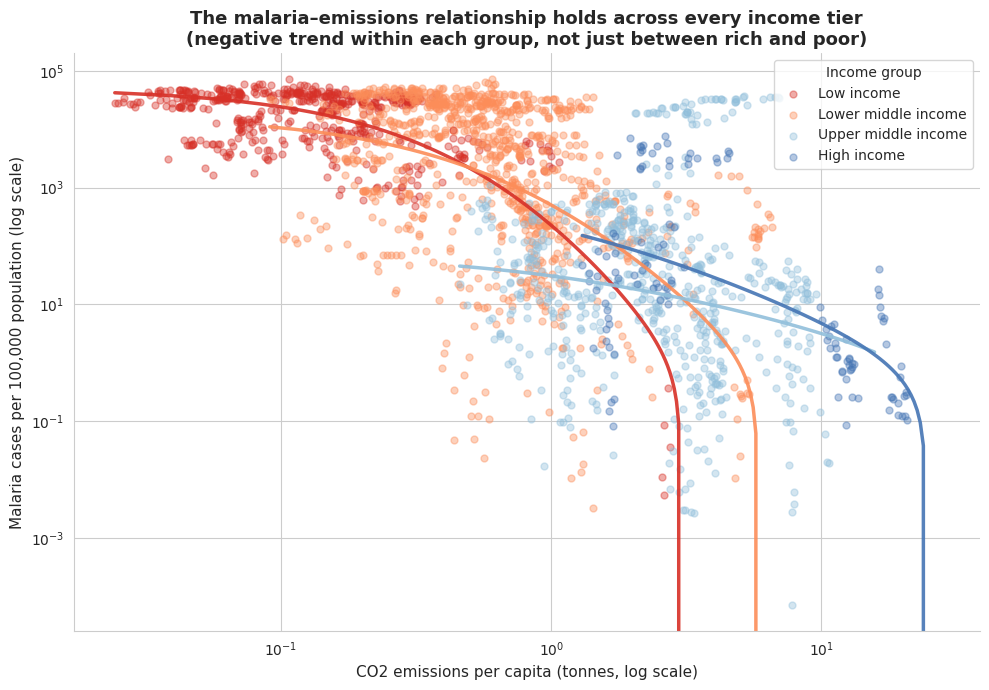

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
income_colors = {
    "Low income": "#d73027",
    "Lower middle income": "#fc8d59",
    "Upper middle income": "#91bfdb",
    "High income": "#4575b4",
}

d = subsets["malaria"]
fig, ax = plt.subplots(figsize=(10, 7))

for group in income_order:
    sub = d[d["IncomeGroup"] == group]
    if len(sub) < 10:
        continue
    ax.scatter(sub["co2_per_capita"], sub["malaria_per_100k"],
               alpha=0.4, s=25, color=income_colors[group], label=group)
    log_x = np.log1p(sub["co2_per_capita"])
    log_y = np.log1p(sub["malaria_per_100k"])
    if len(sub) > 5:
        z = np.polyfit(log_x, log_y, 1)
        x_line = np.linspace(log_x.min(), log_x.max(), 100)
        ax.plot(np.expm1(x_line), np.expm1(np.polyval(z, x_line)),
                color=income_colors[group], linewidth=2.5, alpha=0.9)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("CO2 emissions per capita (tonnes, log scale)", fontsize=11)
ax.set_ylabel("Malaria cases per 100,000 population (log scale)", fontsize=11)
ax.set_title("The malaria–emissions relationship holds across every income tier\n"
             "(negative trend within each group, not just between rich and poor)",
             fontsize=13, fontweight="bold")
ax.legend(title="Income group", frameon=True, loc="upper right")
sns.despine()
plt.tight_layout()
plt.savefig("chart_malaria_consistency.png", dpi=150, bbox_inches="tight")
plt.show()

In [34]:
d = subsets["air_pollution"]
emitter_rank = d.groupby("country_code")["co2_emissions"].mean().sort_values(ascending=False)
counts = d["country_code"].value_counts()
eligible = counts[counts >= 15].index  # at least 15 years of coverage
co2_std = d.groupby("country_code")["co2_per_capita"].std()
has_real_variation = co2_std[co2_std > 0.01].index
major_emitters = [c for c in emitter_rank.index if c in eligible][:3]
minor_emitters = [c for c in emitter_rank.index[::-1] if c in eligible and c in has_real_variation][:3]
print("Major emitters:", major_emitters)
print("Minor emitters:", minor_emitters)

Major emitters: ['CHN', 'USA', 'RUS']
Minor emitters: ['KIR', 'DMA', 'KNA']


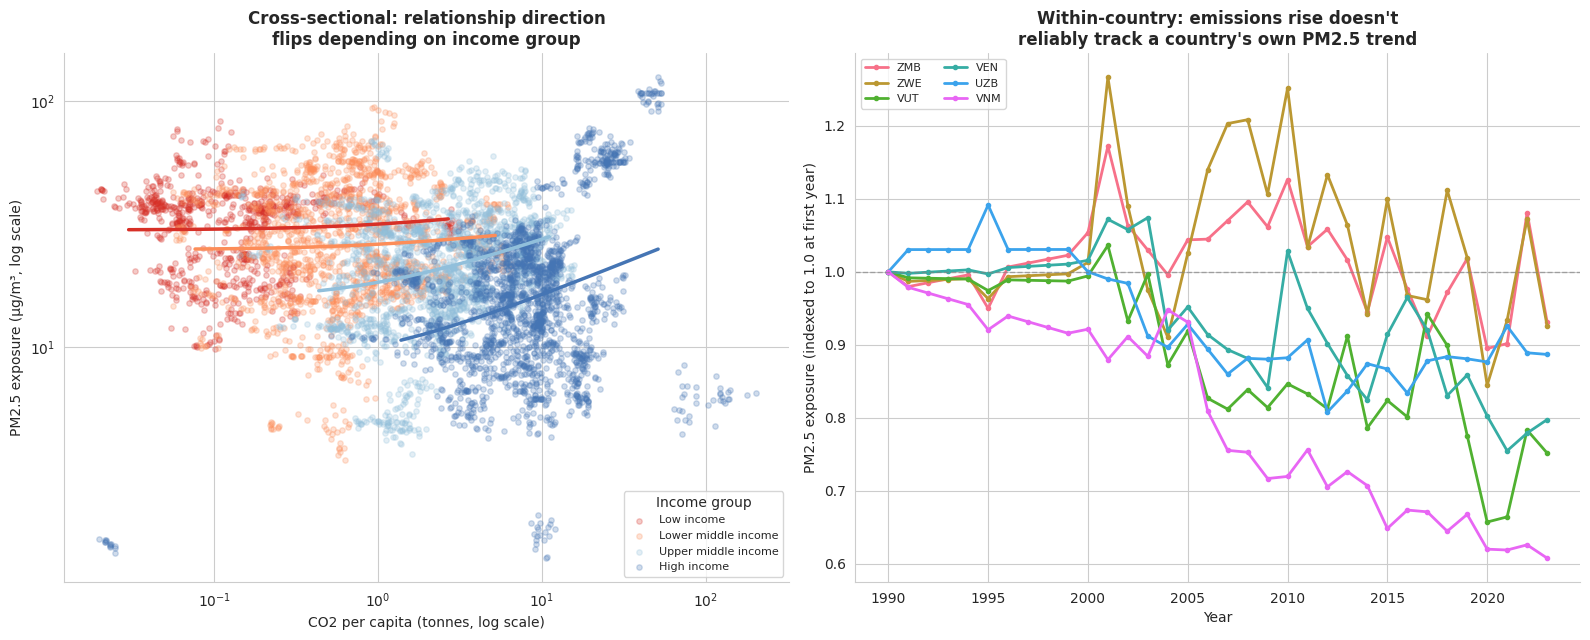

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
d = subsets["air_pollution"]
ax = axes[0]

for group in income_order:
    sub = d[d["IncomeGroup"] == group]
    if len(sub) < 10:
        continue
    ax.scatter(sub["co2_per_capita"], sub["pm25_exposure"],
               alpha=0.25, s=15, color=income_colors[group], label=group)

    log_x = np.log1p(sub["co2_per_capita"])
    log_y = np.log1p(sub["pm25_exposure"])
    z = np.polyfit(log_x, log_y, 1)
    x_line = np.linspace(log_x.quantile(0.02), log_x.quantile(0.98), 100)
    ax.plot(np.expm1(x_line), np.expm1(np.polyval(z, x_line)),
            color=income_colors[group], linewidth=2.5)

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("CO2 per capita (tonnes, log scale)")
ax.set_ylabel("PM2.5 exposure (µg/m³, log scale)")
ax.set_title("Cross-sectional: relationship direction\nflips depending on income group",
             fontsize=12, fontweight="bold")
ax.legend(title="Income group", fontsize=8, loc="lower right")
ax2 = axes[1]
top_countries = d["country_code"].value_counts().head(6).index
palette = sns.color_palette("husl", len(top_countries))
for cc, color in zip(top_countries, palette):
    sub = d[d["country_code"] == cc].sort_values("year")
    co2_norm = sub["co2_per_capita"] / sub["co2_per_capita"].iloc[0]
    pm25_norm = sub["pm25_exposure"] / sub["pm25_exposure"].iloc[0]
    ax2.plot(sub["year"], pm25_norm, color=color, linewidth=2, label=cc, marker="o", markersize=3)

ax2.axhline(1.0, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax2.set_xlabel("Year")
ax2.set_ylabel("PM2.5 exposure (indexed to 1.0 at first year)")
ax2.set_title("Within-country: emissions rise doesn't\nreliably track a country's own PM2.5 trend",
              fontsize=12, fontweight="bold")
ax2.legend(fontsize=8, loc="upper left", ncol=2)

sns.despine()
plt.tight_layout()
plt.savefig("chart_air_pollution_divergence.png", dpi=150, bbox_inches="tight")
plt.show()

In [36]:
import pycountry
suspect_codes = {"NRU", "VIR", "MNP", "ASM", "GUM"}
before = len(subsets["air_pollution"])
subsets["air_pollution"] = subsets["air_pollution"][
    ~subsets["air_pollution"]["country_code"].isin(suspect_codes)
].copy()
after = len(subsets["air_pollution"])
print(f"Dropped {before - after} rows from {len(suspect_codes)} territories/countries "
      f"with unreliable near-zero CO2 reporting")

Dropped 0 rows from 5 territories/countries with unreliable near-zero CO2 reporting


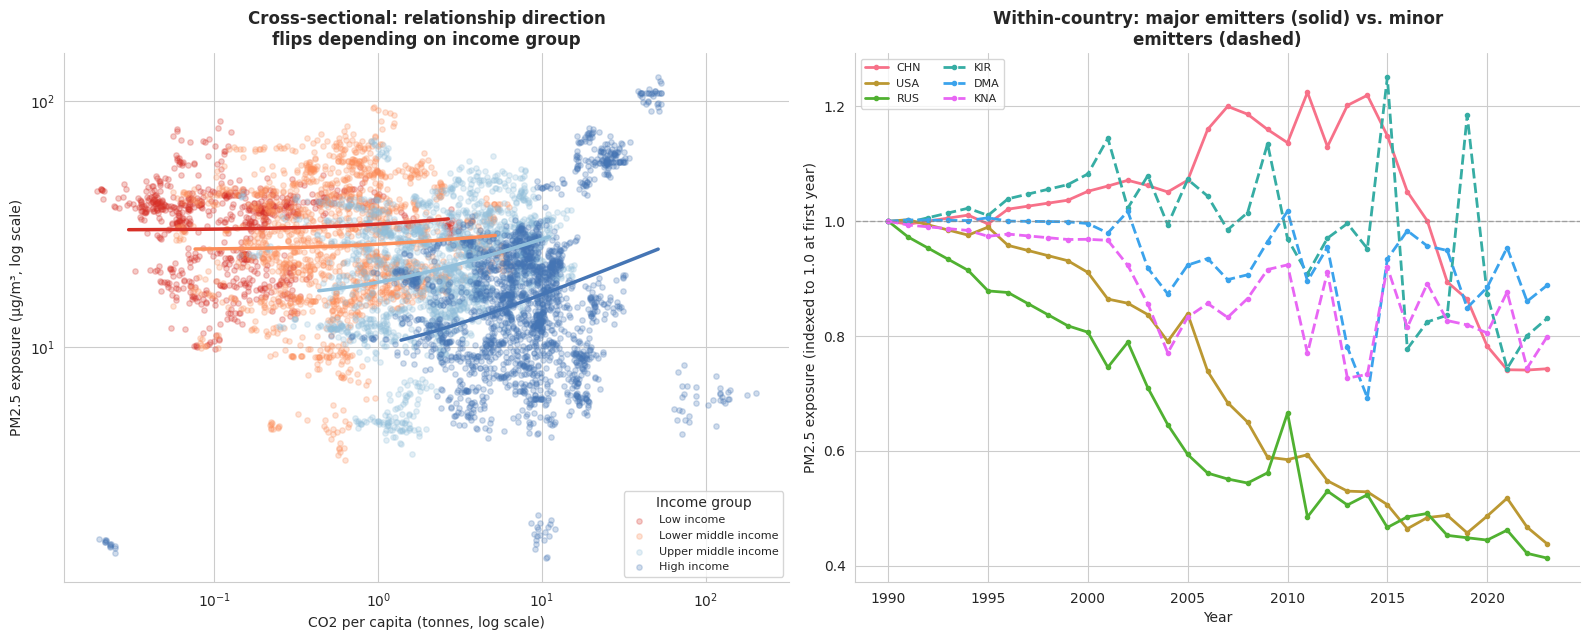

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
d = subsets["air_pollution"]
ax = axes[0]
for group in income_order:
    sub = d[d["IncomeGroup"] == group]
    if len(sub) < 10:
        continue
    ax.scatter(sub["co2_per_capita"], sub["pm25_exposure"],
               alpha=0.25, s=15, color=income_colors[group], label=group)
    log_x = np.log1p(sub["co2_per_capita"])
    log_y = np.log1p(sub["pm25_exposure"])
    z = np.polyfit(log_x, log_y, 1)
    x_line = np.linspace(log_x.quantile(0.02), log_x.quantile(0.98), 100)
    ax.plot(np.expm1(x_line), np.expm1(np.polyval(z, x_line)),
            color=income_colors[group], linewidth=2.5)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("CO2 per capita (tonnes, log scale)")
ax.set_ylabel("PM2.5 exposure (µg/m³, log scale)")
ax.set_title("Cross-sectional: relationship direction\nflips depending on income group",
             fontsize=12, fontweight="bold")
ax.legend(title="Income group", fontsize=8, loc="lower right")
ax2 = axes[1]
selected_countries = major_emitters + minor_emitters
palette = sns.color_palette("husl", len(selected_countries))
for cc, color in zip(selected_countries, palette):
    sub = d[d["country_code"] == cc].sort_values("year")
    co2_norm = sub["co2_per_capita"] / sub["co2_per_capita"].iloc[0]
    pm25_norm = sub["pm25_exposure"] / sub["pm25_exposure"].iloc[0]
    linestyle = "-" if cc in major_emitters else "--"
    ax2.plot(sub["year"], pm25_norm, color=color, linewidth=2, label=cc,
              marker="o", markersize=3, linestyle=linestyle)
ax2.axhline(1.0, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax2.set_xlabel("Year")
ax2.set_ylabel("PM2.5 exposure (indexed to 1.0 at first year)")
ax2.set_title("Within-country: major emitters (solid) vs. minor\nemitters (dashed)",
              fontsize=12, fontweight="bold")
ax2.legend(fontsize=8, loc="upper left", ncol=2)
sns.despine()
plt.tight_layout()
plt.savefig("chart_air_pollution_divergence.png", dpi=150, bbox_inches="tight")
plt.show()

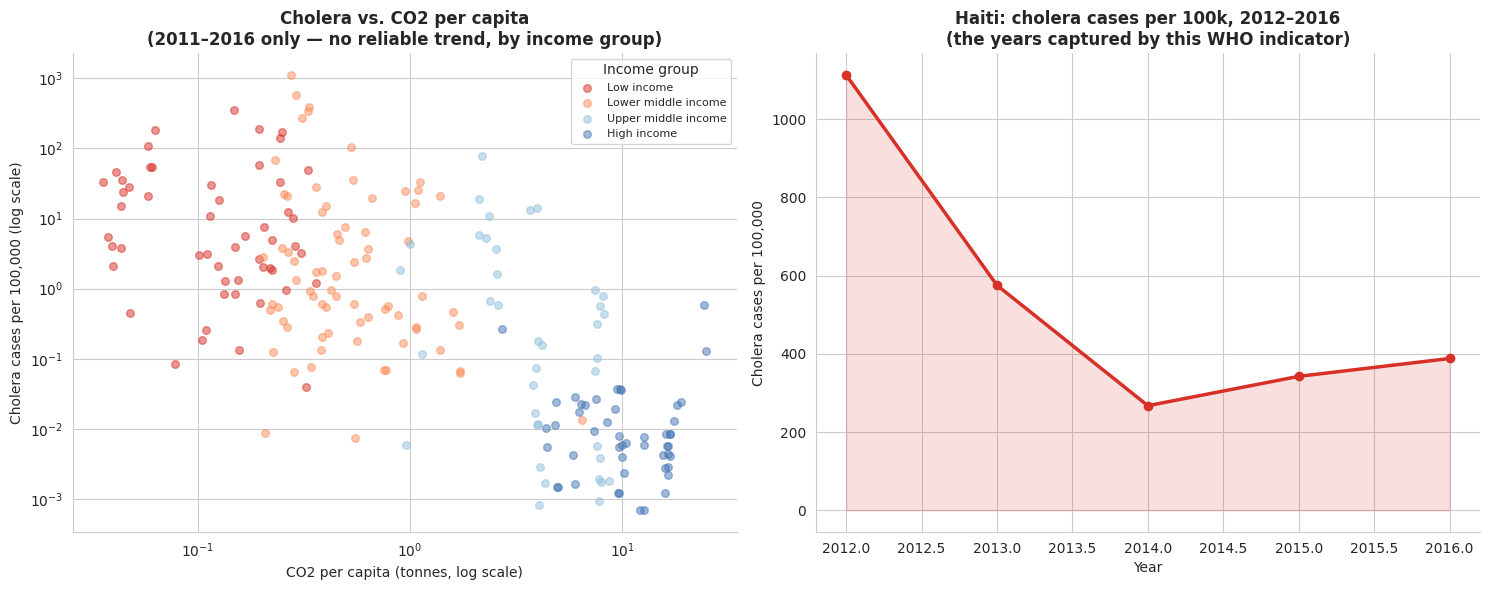

In [38]:
d = subsets["cholera"]
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ax = axes[0]
for group in income_order:
    sub = d[d["IncomeGroup"] == group]
    if len(sub) < 5:
        continue
    ax.scatter(sub["co2_per_capita"], sub["cholera_per_100k"],
               alpha=0.5, s=30, color=income_colors[group], label=group)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("CO2 per capita (tonnes, log scale)")
ax.set_ylabel("Cholera cases per 100,000 (log scale)")
ax.set_title("Cholera vs. CO2 per capita\n(2011–2016 only — no reliable trend, by income group)",
             fontsize=12, fontweight="bold")
ax.legend(title="Income group", fontsize=8)
haiti = d[d["country_code"] == "HTI"].sort_values("year")
ax2 = axes[1]
ax2.plot(haiti["year"], haiti["cholera_per_100k"], marker="o", color="#d73027", linewidth=2.5)
ax2.set_xlabel("Year")
ax2.set_ylabel("Cholera cases per 100,000")
ax2.set_title("Haiti: cholera cases per 100k, 2012–2016\n(the years captured by this WHO indicator)",
              fontsize=12, fontweight="bold")
ax2.fill_between(haiti["year"], haiti["cholera_per_100k"], alpha=0.15, color="#d73027")
sns.despine()
plt.tight_layout()
plt.savefig("chart_cholera_snapshot.png", dpi=150, bbox_inches="tight")
plt.show()

In [39]:
income_rows = []
for name, df in subsets.items():
    y_col = outcome_cols[name]
    x_col = x_cols[name]
    d = df.copy()
    r_all, p_all = stats.spearmanr(d[x_col], d[y_col])
    income_rows.append({"IncomeGroup": "Overall (pooled)", "Outcome": name,
                         "Correlation": r_all, "P_value": p_all, "Observations": len(d)})
    for group in income_order:
        sub = d[d["IncomeGroup"] == group]
        if len(sub) < 10:
            continue
        r, p = stats.spearmanr(sub[x_col], sub[y_col])
        income_rows.append({"IncomeGroup": group, "Outcome": name,
                             "Correlation": r, "P_value": p, "Observations": len(sub)})
income_group_correlations = pd.DataFrame(income_rows)
income_group_correlations.to_csv("income_group_correlations_verified.csv", index=False)
income_group_correlations.head(10)

,IncomeGroup,Outcome,Correlation,P_value,Observations
0,Overall (pooled),malaria,-0.739569,0.000000e+00,2605
1,Low income,malaria,-0.385240,4.833806e-21,554
2,Lower middle income,malaria,-0.536580,2.436792e-79,1050
3,Upper middle income,malaria,-0.308873,1.020401e-19,826
4,High income,malaria,-0.717687,5.431450e-29,175
5,Overall (pooled),cholera,-0.703696,3.715139e-33,213
6,Low income,cholera,-0.142316,3.093653e-01,53
7,Lower middle income,cholera,-0.194002,1.000497e-01,73
8,Upper middle income,cholera,-0.552686,3.204581e-04,38
9,High income,cholera,-0.057041,6.970577e-01,49


In [40]:
panel_rows = []
for name, df in subsets.items():
    if name == "cholera":
        panel_rows.append({"Outcome": name, "Method": "within-country panel (fixed-effects)",
                            "Slope": None, "Correlation": None, "P_value": None,
                            "N_obs": None, "N_countries": None,
                            "Note": "Skipped — only 2011-2016 data, insufficient years for panel analysis"})
        continue
    y_col = outcome_cols[name]
    x_col = x_cols[name]
    d = df.copy()
    d["log_x"] = np.log1p(d[x_col])
    d["log_y"] = np.log1p(d[y_col]) if y_col != "life_expectancy" else d[y_col]
    result = within_country_regression(d, "log_x", "log_y", name)
    panel_rows.append({"Outcome": name, "Method": "within-country panel (fixed-effects)",
                        "Slope": result["slope"], "Correlation": result["r"], "P_value": result["p"],
                        "N_obs": None, "N_countries": None, "Note": ""})
within_country_panel_verified = pd.DataFrame(panel_rows)
within_country_panel_verified.to_csv("within_country_panel_verified.csv", index=False)
within_country_panel_verified


=== malaria: within-country panel ===
  slope=-3.7320  r=-0.463  p=0.0000  (n=2604 obs, 105 countries)

=== air_pollution: within-country panel ===
  slope=+0.0135  r=+0.017  p=0.1918  (n=6209 obs, 184 countries)

=== life_expectancy: within-country panel ===
  slope=+3.5568  r=+0.177  p=0.0000  (n=3946 obs, 180 countries)


,Outcome,Method,Slope,Correlation,P_value,N_obs,N_countries,Note
0,malaria,within-country panel (fixed-effects),-3.732033,-0.463398,8.741626e-139,None,None,
1,cholera,within-country panel (fixed-effects),NaN,NaN,NaN,None,None,"Skipped — only 2011-2016 data, insufficient ye..."
2,air_pollution,within-country panel (fixed-effects),0.013501,0.016568,1.917767e-01,None,None,
3,life_expectancy,within-country panel (fixed-effects),3.556753,0.177035,3.812449e-29,None,None,


In [41]:
regression_results = {}
for name, df in subsets.items():
    y_col = outcome_cols[name]
    x_col = x_cols[name]
    d = df.copy()
    d["log_co2"] = np.log1p(d[x_col])
    d["log_gdp"] = np.log1p(d["gdp_per_capita"])
    d["y"] = np.log1p(d[y_col]) if y_col != "life_expectancy" else d[y_col]
    X = sm.add_constant(d[["log_co2", "log_gdp"]])
    model = sm.OLS(d["y"], X).fit(cov_type="HC3")
    regression_results[name] = model
    print(f"{name}: n={int(model.nobs)}")

malaria: n=2605
cholera: n=213
air_pollution: n=6209
life_expectancy: n=3946


In [42]:
regression_rows = []
for name, model in regression_results.items():
    co2_row = model.params.get("log_co2", None)
    gdp_row = model.params.get("log_gdp", None)
    regression_rows.append({
        "Outcome": name,
        "CO2_coefficient": model.params["log_co2"],
        "CO2_pvalue": model.pvalues["log_co2"],
        "GDP_coefficient": model.params["log_gdp"],
        "GDP_pvalue": model.pvalues["log_gdp"],
        "R_squared": model.rsquared,
        "N_obs": int(model.nobs),
    })
regression_summary_verified = pd.DataFrame(regression_rows)
regression_summary_verified.to_csv("regression_summary_verified.csv", index=False)
regression_summary_verified

,Outcome,CO2_coefficient,CO2_pvalue,GDP_coefficient,GDP_pvalue,R_squared,N_obs
0,malaria,-2.966911,7.954592e-122,-0.617408,1.295608e-13,0.487230,2605
1,cholera,-0.731225,2.242004e-04,-0.076985,4.913751e-01,0.270731,213
2,air_pollution,0.254557,7.736822e-46,-0.280927,2.933309e-279,0.261279,6209
3,life_expectancy,0.515159,7.904683e-04,4.272466,0.000000e+00,0.640189,3946


In [43]:
vif_rows = []
for name, df in subsets.items():
    d = df.copy()
    d["log_co2"] = np.log1p(d[x_cols[name]])
    d["log_gdp"] = np.log1p(d["gdp_per_capita"])
    X = sm.add_constant(d[["log_co2", "log_gdp"]])
    vif_co2 = variance_inflation_factor(X.values, 1)
    vif_gdp = variance_inflation_factor(X.values, 2)
    vif_rows.append({"Outcome": name, "VIF_co2": vif_co2, "VIF_gdp": vif_gdp})
vif_summary = pd.DataFrame(vif_rows)
vif_summary.to_csv("vif_summary.csv", index=False)
vif_summary

,Outcome,VIF_co2,VIF_gdp
0,malaria,2.816589,2.816589
1,cholera,7.567565,7.567565
2,air_pollution,2.461596,2.461596
3,life_expectancy,3.228324,3.228324


In [44]:
panel_rows = []
for name, df in subsets.items():
    if name == "cholera":
        panel_rows.append({"Outcome": name, "Method": "within-country panel (fixed-effects)",
                            "Slope": None, "Correlation": None, "P_value": None,
                            "N_obs": None, "N_countries": None,
                            "Note": "Skipped — only 2011-2016 data, insufficient years for panel analysis"})
        continue
    y_col = outcome_cols[name]
    x_col = x_cols[name]
    d = df.copy()
    d["log_x"] = np.log1p(d[x_col])
    d["log_y"] = np.log1p(d[y_col]) if y_col != "life_expectancy" else d[y_col]
    counts = d["country_code"].value_counts()
    valid = counts[counts >= 2].index
    d_valid = d[d["country_code"].isin(valid)]
    result = within_country_regression(d, "log_x", "log_y", name)
    panel_rows.append({"Outcome": name, "Method": "within-country panel (fixed-effects)",
                        "Slope": result["slope"], "Correlation": result["r"], "P_value": result["p"],
                        "N_obs": len(d_valid), "N_countries": d_valid["country_code"].nunique(), "Note": ""})
within_country_panel_verified = pd.DataFrame(panel_rows)
within_country_panel_verified.to_csv("within_country_panel_verified.csv", index=False)
within_country_panel_verified


=== malaria: within-country panel ===
  slope=-3.7320  r=-0.463  p=0.0000  (n=2604 obs, 105 countries)

=== air_pollution: within-country panel ===
  slope=+0.0135  r=+0.017  p=0.1918  (n=6209 obs, 184 countries)

=== life_expectancy: within-country panel ===
  slope=+3.5568  r=+0.177  p=0.0000  (n=3946 obs, 180 countries)


,Outcome,Method,Slope,Correlation,P_value,N_obs,N_countries,Note
0,malaria,within-country panel (fixed-effects),-3.732033,-0.463398,8.741626e-139,2604.0,105.0,
1,cholera,within-country panel (fixed-effects),NaN,NaN,NaN,NaN,NaN,"Skipped — only 2011-2016 data, insufficient ye..."
2,air_pollution,within-country panel (fixed-effects),0.013501,0.016568,1.917767e-01,6209.0,184.0,
3,life_expectancy,within-country panel (fixed-effects),3.556753,0.177035,3.812449e-29,3946.0,180.0,


In [45]:
haiti_full = who_master[who_master["country_code"] == "HTI"][["year", "cholera_cases"]].dropna()
print(haiti_full.sort_values("year"))

      year  cholera_cases
2301  2012       112076.0
2302  2013        58809.0
2303  2014        27753.0
2304  2015        36045.0
2305  2016        41421.0


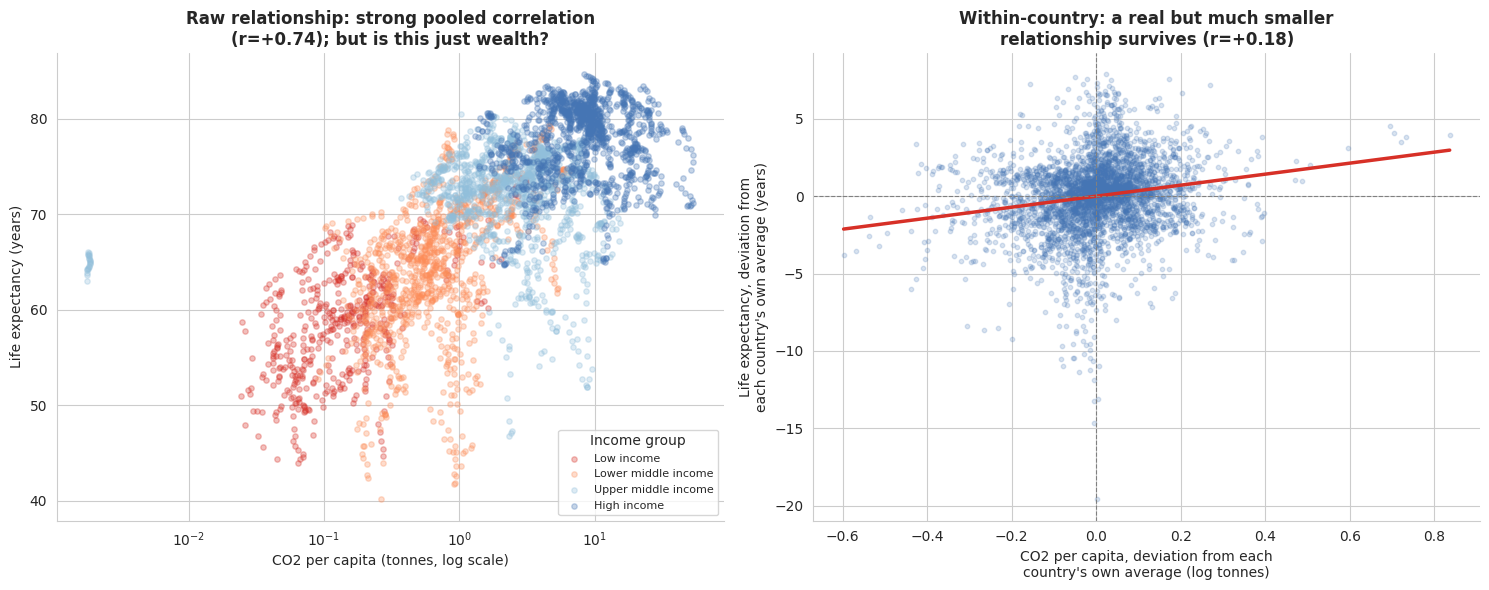

In [46]:
d = subsets["life_expectancy"].copy()
d["log_co2"] = np.log1p(d["co2_per_capita"])
d["co2_demeaned"] = d["log_co2"] - d.groupby("country_code")["log_co2"].transform("mean")
d["life_demeaned"] = d["life_expectancy"] - d.groupby("country_code")["life_expectancy"].transform("mean")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ax = axes[0]
for group in income_order:
    sub = d[d["IncomeGroup"] == group]
    if len(sub) < 10:
        continue
    ax.scatter(sub["co2_per_capita"], sub["life_expectancy"],
               alpha=0.3, s=15, color=income_colors[group], label=group)
ax.set_xscale("log")
ax.set_xlabel("CO2 per capita (tonnes, log scale)")
ax.set_ylabel("Life expectancy (years)")
ax.set_title("Raw relationship: strong pooled correlation\n(r=+0.74); but is this just wealth?",
             fontsize=12, fontweight="bold")
ax.legend(title="Income group", fontsize=8, loc="lower right")
ax2 = axes[1]
ax2.scatter(d["co2_demeaned"], d["life_demeaned"], alpha=0.2, s=10, color="#4575b4")
z = np.polyfit(d["co2_demeaned"], d["life_demeaned"], 1)
x_line = np.linspace(d["co2_demeaned"].min(), d["co2_demeaned"].max(), 100)
ax2.plot(x_line, np.polyval(z, x_line), color="#d73027", linewidth=2.5)
ax2.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax2.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax2.set_xlabel("CO2 per capita, deviation from each\ncountry's own average (log tonnes)")
ax2.set_ylabel("Life expectancy, deviation from\neach country's own average (years)")
ax2.set_title("Within-country: a real but much smaller\nrelationship survives (r=+0.18)",
              fontsize=12, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.savefig("chart_life_expectancy_confound.png", dpi=150, bbox_inches="tight")
plt.show()

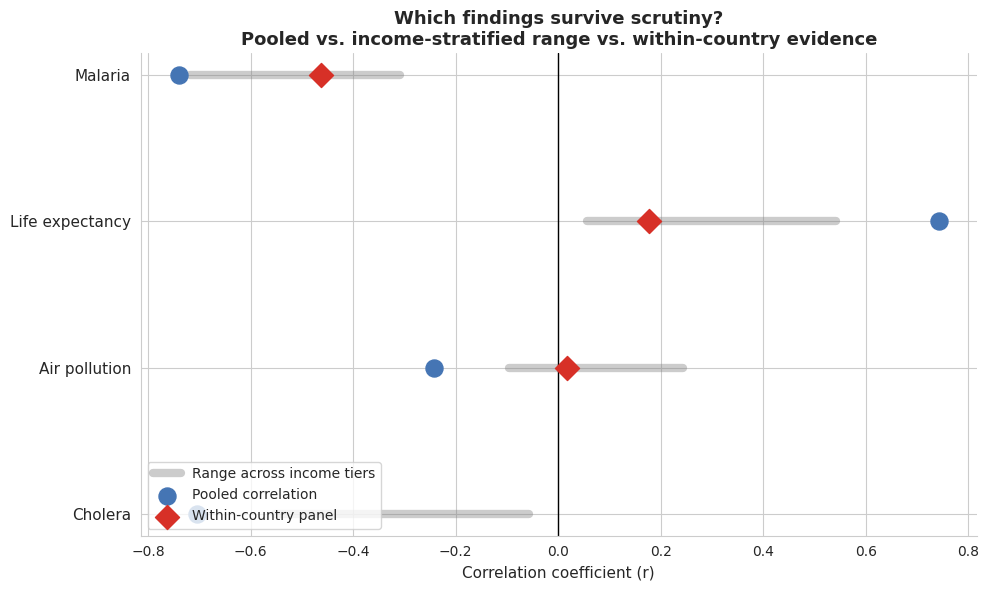

In [47]:
summary_data = {
    "Malaria":         {"pooled": -0.740, "stratified_range": (-0.718, -0.309), "within_country": -0.463},
    "Life expectancy": {"pooled": +0.742, "stratified_range": (+0.057, +0.541), "within_country": +0.177},
    "Air pollution":   {"pooled": -0.242, "stratified_range": (-0.096, +0.244), "within_country": +0.017},  # updated post-cleanup
    "Cholera":         {"pooled": -0.704, "stratified_range": (-0.553, -0.057), "within_country": None},
}
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(summary_data))
for i, (name, vals) in enumerate(summary_data.items()):
    ax.plot(vals["stratified_range"], [i, i], color="gray", linewidth=6, alpha=0.4,
            label="Range across income tiers" if i == 0 else "")
    ax.scatter(vals["pooled"], i, color="#4575b4", s=150, zorder=3,
               label="Pooled correlation" if i == 0 else "")
    if vals["within_country"] is not None:
        ax.scatter(vals["within_country"], i, color="#d73027", s=150, marker="D", zorder=3,
                   label="Within-country panel" if i == 0 else "")
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(summary_data.keys(), fontsize=11)
ax.invert_yaxis()
ax.set_xlabel("Correlation coefficient (r)", fontsize=11)
ax.set_title("Which findings survive scrutiny?\nPooled vs. income-stratified range vs. within-country evidence",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower left", frameon=True)
sns.despine()
plt.tight_layout()
plt.savefig("chart_summary_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

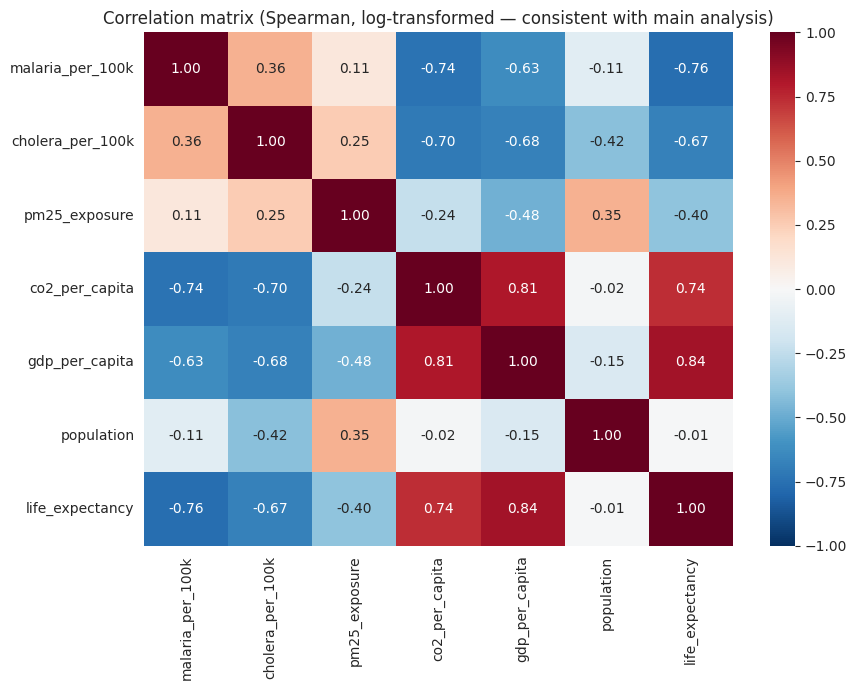

In [48]:
merge_cols = ["country_code", "year"]
heatmap_df = subsets["malaria"][merge_cols + ["malaria_per_100k"]]
for name, col in [("cholera", "cholera_per_100k"), ("life_expectancy", "life_expectancy")]:
    heatmap_df = heatmap_df.merge(subsets[name][merge_cols + [col]], on=merge_cols, how="outer")
heatmap_df = heatmap_df.merge(
    subsets["air_pollution"][merge_cols + ["pm25_exposure", "co2_per_capita", "gdp_per_capita", "population"]],
    on=merge_cols, how="outer"
)
skewed_cols = ["malaria_per_100k", "cholera_per_100k", "pm25_exposure", "co2_per_capita", "gdp_per_capita", "population"]
for col in skewed_cols:
    heatmap_df[f"log_{col}"] = np.log1p(heatmap_df[col])
log_cols = [f"log_{c}" for c in skewed_cols] + ["life_expectancy"]
corr_matrix = heatmap_df[log_cols].corr(method="spearman")
corr_matrix.columns = [c.replace("log_", "") for c in corr_matrix.columns]
corr_matrix.index = [c.replace("log_", "") for c in corr_matrix.index]
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation matrix (Spearman, log-transformed — consistent with main analysis)")
plt.tight_layout()
plt.savefig("chart_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()